<a href="https://colab.research.google.com/github/Idguerrero333/NOTEBOOKPYTHONINTERACTIVE/blob/main/Challenge2_TelecomX_Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#CHALLENGE 1 TELECOM X PARTE I

##Limpieza y Tratamiento de Datos

In [ ]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Cargar datos desde la API
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()

# Normalizar el JSON anidado
df = pd.json_normalize(data)

# Mostrar las primeras filas
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


##Explorar Columnas y Tipos de Datos
Verificamos la estructura del dataset. Las columnas incluyen:
* customerID,
* gender,
* SeniorCitizen,
* Partner,
* Dependents,
* tenure,
* PhoneService,
* MultipleLines,
* InternetService,
* OnlineSecurity,
* OnlineBackup,
* DeviceProtection,
* TechSupport,
* StreamingTV,
* StreamingMovies,
* Contract,
* PaperlessBilling,
* PaymentMethod,
* MonthlyCharges,
* TotalCharges,
* Churn.

(Diccionario de datos asumido basado en estructura estándar: gender - Género, SeniorCitizen - Ciudadano mayor (0/1), Partner - Pareja (Yes/No), Dependents - Dependientes (Yes/No), tenure - Antigüedad en meses, PhoneService - Servicio telefónico (Yes/No), MultipleLines - Líneas múltiples (Yes/No/No phone service), InternetService - Tipo de internet (DSL/Fiber optic/No), OnlineSecurity/Backup/Protection/TechSupport/StreamingTV/Movies - Servicios adicionales (Yes/No/No internet service), Contract - Tipo de contrato (Month-to-month/One year/Two year), PaperlessBilling - Facturación sin papel (Yes/No), PaymentMethod - Método de pago (Electronic check/Mailed check/Bank transfer/Credit card), MonthlyCharges - Cargos mensuales, TotalCharges - Cargos totales, Churn - Evasión (Yes/No).)

In [ ]:
# Información del DataFrame
df.info()

# Tipos de datos
print(df.dtypes)

# Columnas relevantes para churn: todas, pero enfocadas en demográficas, servicios, contrato, pagos y cargos.
relevant_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                    'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
                    'MonthlyCharges', 'TotalCharges', 'Churn']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [ ]:
# Prefijos a eliminar
prefijos = ['customer.', 'phone.', 'internet.', 'account.', 'Charges.']

# Listas para el mapeo (emparejamiento)
nombres_actuales = []
nombres_limpios = []

# Iterar sobre las columnas del DataFrame
for col in df.columns:
    es_prefijo = False

    # Verificar si la columna comienza con alguno de los prefijos
    for prefijo in prefijos:
        if col.startswith(prefijo):
            nombres_actuales.append(col)
            # Eliminar el prefijo para obtener el nombre limpio
            nombres_limpios.append(col.replace(prefijo, '', 1))
            es_prefijo = True
            break

    # Si la columna no tiene prefijo (ej: customerID, Churn), se mantiene igual
    if not es_prefijo:
        nombres_actuales.append(col)
        nombres_limpios.append(col)


# Usar zip() para crear el diccionario de mapeo
# Empareja (zip) los nombres actuales con los nombres limpios
mapeo_renombre = dict(zip(nombres_actuales, nombres_limpios))

# Renombrado con .rename()
# Le pasamos el diccionario de mapeo generado por zip
df = df.rename(columns=mapeo_renombre)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


##Comprobación de Incoherencias
Verificamos valores ausentes, duplicados, formatos incorrectos e inconsistencias en categorías.
Python

In [ ]:
# Valores ausentes
print(df.isnull().sum())

# Duplicados
print(df.duplicated().sum())

# Valores únicos en categóricas
for col in ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']:
    print(f'{col}: {df[col].unique()}')

# TotalCharges es string, convertir a float (manejar espacios vacíos)
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'].str.strip(), errors='coerce')

# Normalizar fechas si aplica (no hay en este dataset)

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64
0
gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['Yes' 'No']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'Yes' 'No phone service']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['Yes' 'No' 'No internet service']
StreamingTV: ['Yes' 'No' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['One year' 'Month-to

##Manejo de Inconsistencias
Limpiamos: convertimos TotalCharges a numérico, manejamos valores vacíos en Churn (asumir No o drop), estandarizamos strings.

In [ ]:
# Manejar vacíos en Churn (asumir 'No' o drop; aquí drop para simplicidad)
df = df[df['Churn'] != '']

# Manejar 'No phone service' / 'No internet service' como 'No'
service_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = df[col].replace({'No phone service': 'No', 'No internet service': 'No'})

# Manipulación de strings: lower case para consistencia
for col in df.select_dtypes(include='object').columns:
    if col != 'customerID':
        df[col] = df[col].str.lower().str.strip().str.replace(' ', '_')  # Ejemplo: replace spaces

# Drop duplicados si hay
df.drop_duplicates(inplace=True)

##Columna de Cuentas Diarias
Calculamos cargos diarios como MonthlyCharges / 30 (aproximado).

In [ ]:
df['Daily'] = df['Charges.Monthly'] / 30

##Estandarización y Transformación de Datos
Convertimos Yes/No a 1/0, renombramos columnas para claridad.

In [ ]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn'] + service_cols
for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0, '': np.nan})  # Map to binary

# Renombrar columnas (opcional, para español)
df.rename(columns={
    'gender': 'Genero', 'SeniorCitizen': 'CiudadanoMayor', 'Partner': 'Pareja', 'Dependents': 'Dependientes',
    'tenure': 'Antiguedad', 'PhoneService': 'ServicioTelefonico', 'MultipleLines': 'LineasMultiples',
    'InternetService': 'ServicioInternet', 'OnlineSecurity': 'SeguridadOnline', 'OnlineBackup': 'BackupOnline',
    'DeviceProtection': 'ProteccionDispositivo', 'TechSupport': 'SoporteTecnico', 'StreamingTV': 'StreamingTV',
    'StreamingMovies': 'StreamingPeliculas', 'Contract': 'Contrato', 'PaperlessBilling': 'FacturacionSinPapel',
    'PaymentMethod': 'MetodoPago', 'Charges.Monthly': 'CargosMensuales', 'Charges.Total': 'CargosTotales',
    'Churn': 'Evasion', 'Daily': 'CargosDiarios'
}, inplace=True)

##Análisis Exploratorio de Datos
Análisis Descriptivo
Calculamos métricas estadísticas.
Python

In [ ]:
df.describe()

,Evasion,CiudadanoMayor,Pareja,Dependientes,Antiguedad,ServicioTelefonico,LineasMultiples,SeguridadOnline,BackupOnline,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,FacturacionSinPapel,CargosMensuales,CargosTotales,CargosDiarios
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,64.761692,2283.300441,2.158723
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,30.090047,2266.771362,1.003002
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.500000,401.450000,1.183333
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.850000,3794.737500,2.995000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


##Distribución de Evasión
Visualizamos la proporción de churn.

Evasion
0.0    73.463013
1.0    26.536987
Name: proportion, dtype: float64


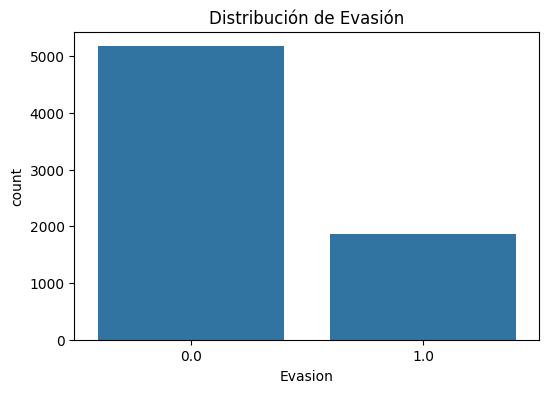

In [ ]:
churn_dist = df['Evasion'].value_counts(normalize=True) * 100
print(churn_dist)

# Gráfico
plt.figure(figsize=(6,4))
sns.countplot(x='Evasion', data=df)
plt.title('Distribución de Evasión')
plt.show()

##Recuento de Evasión por Variables Categóricas
Exploramos churn por género, contrato, método de pago, etc.

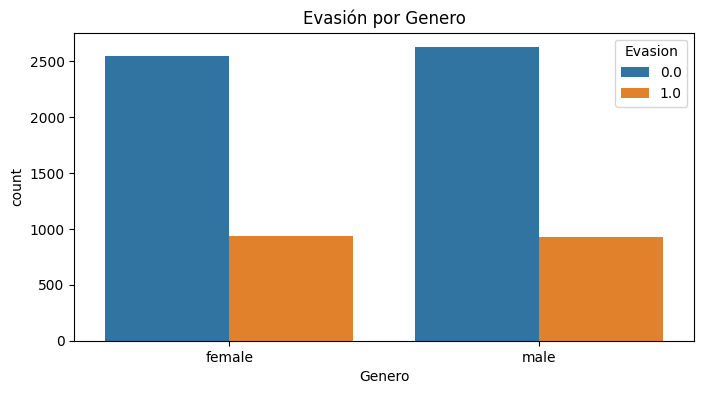

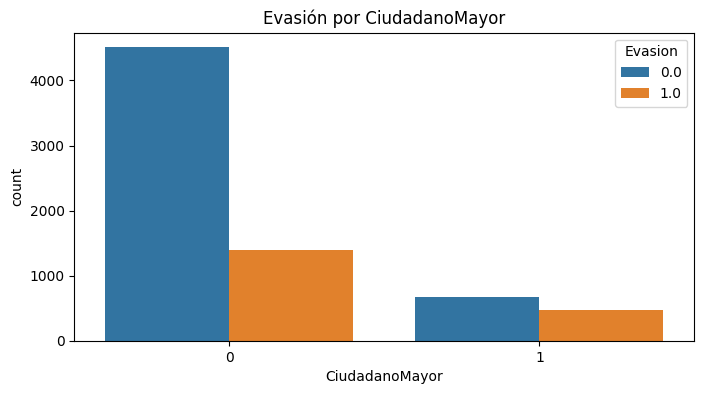

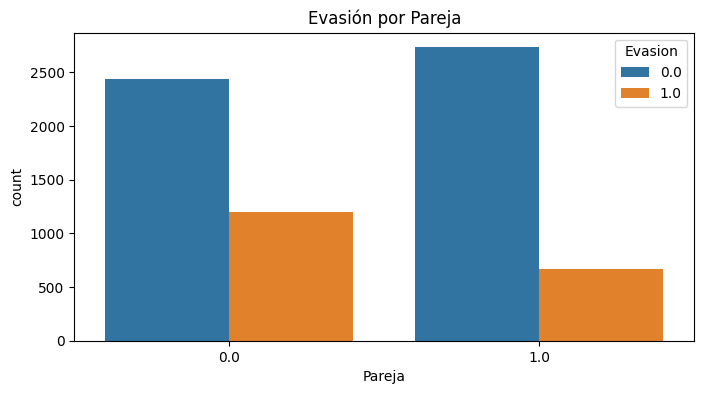

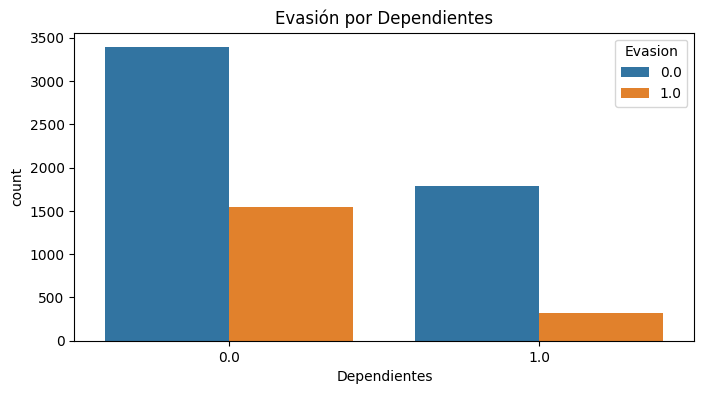

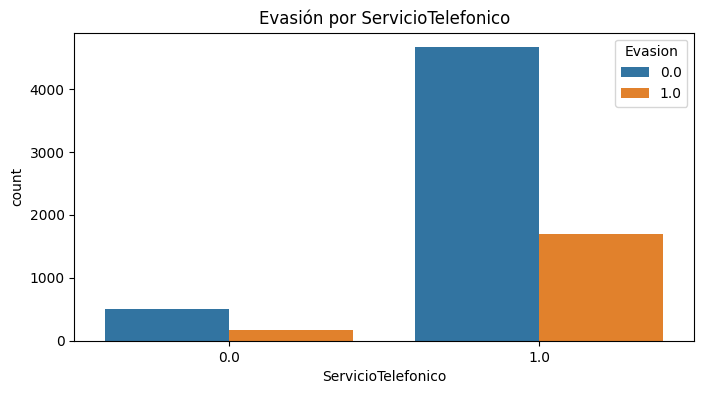

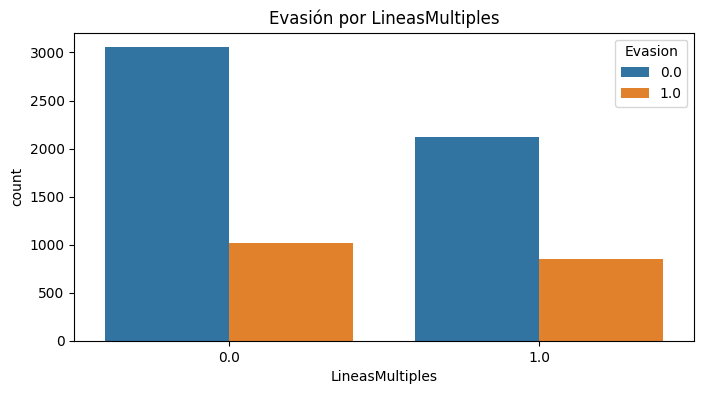

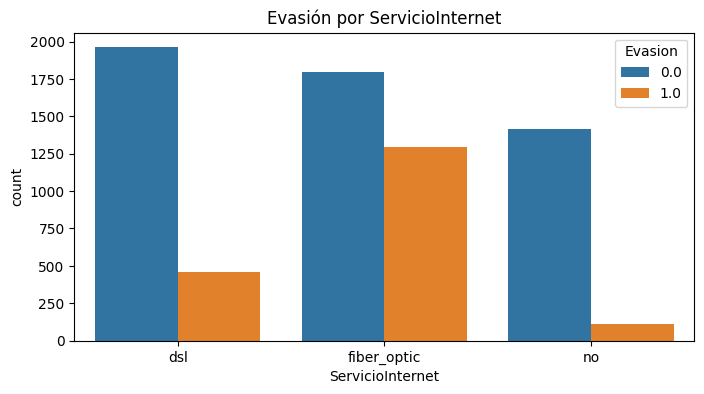

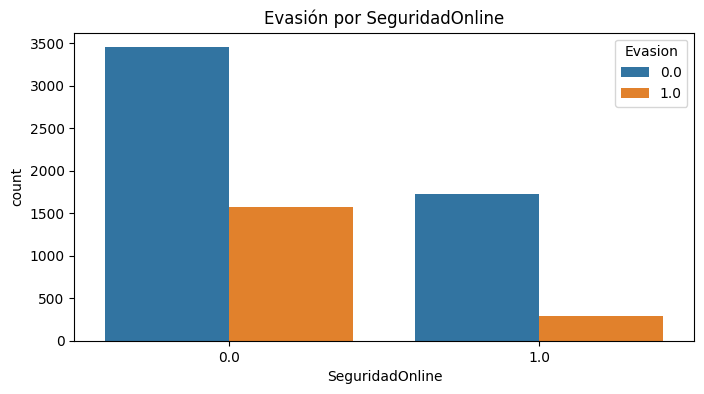

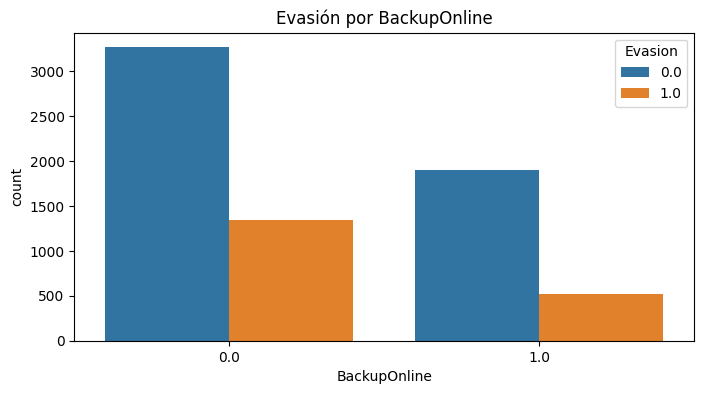

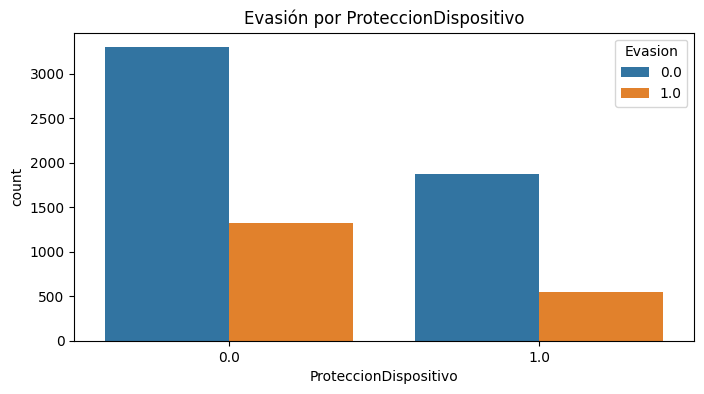

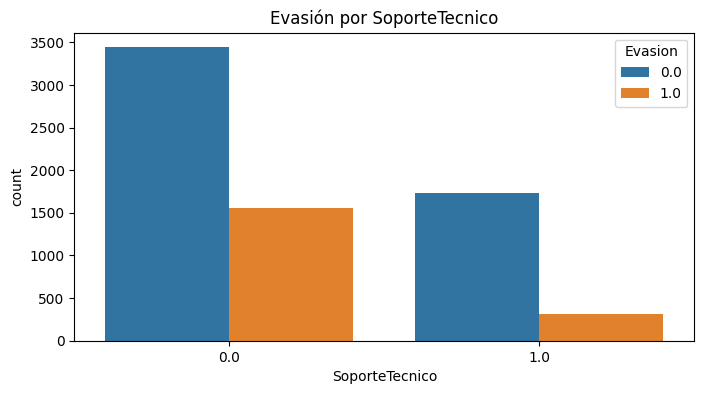

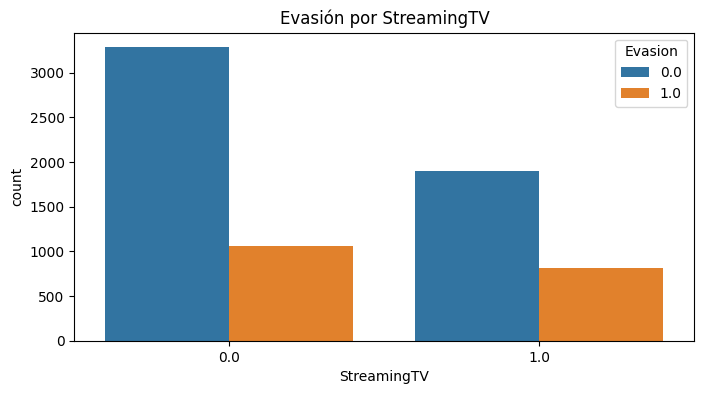

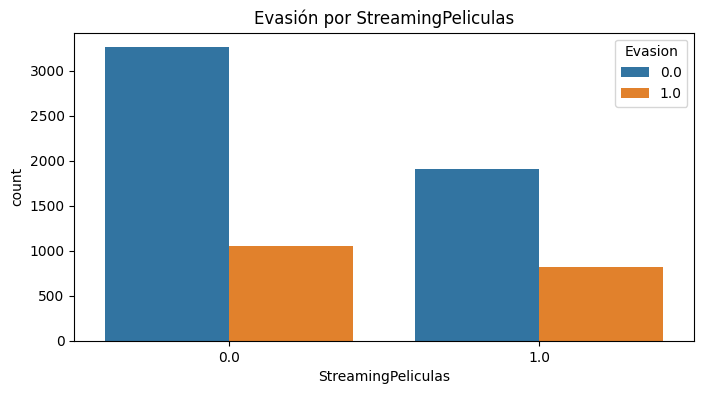

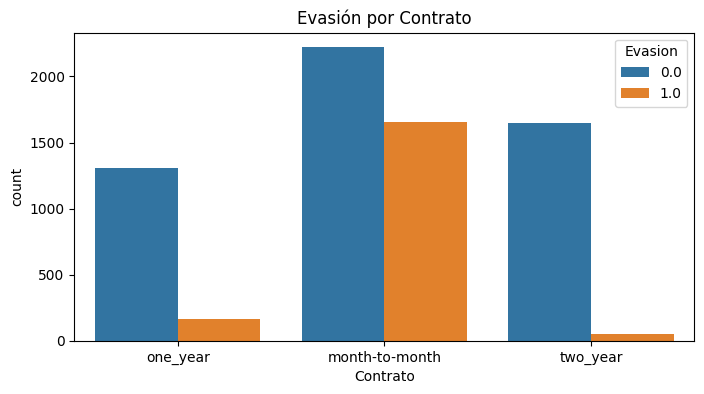

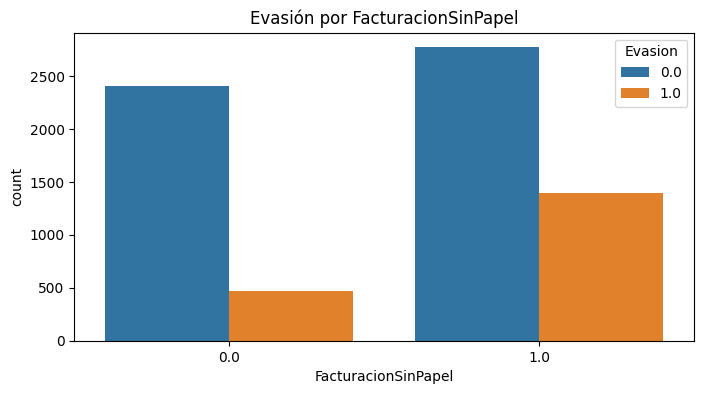

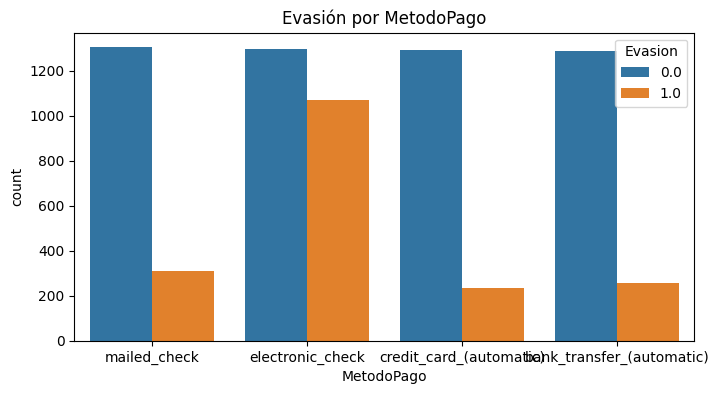

In [ ]:
cat_vars = ['Genero', 'CiudadanoMayor', 'Pareja', 'Dependientes', 'ServicioTelefonico', 'LineasMultiples',
            'ServicioInternet', 'SeguridadOnline', 'BackupOnline', 'ProteccionDispositivo', 'SoporteTecnico',
            'StreamingTV', 'StreamingPeliculas', 'Contrato', 'FacturacionSinPapel', 'MetodoPago']

for var in cat_vars:
    plt.figure(figsize=(8,4))
    sns.countplot(x=var, hue='Evasion', data=df)
    plt.title(f'Evasión por {var}')
    plt.show()

##Conteo de Evasión por Variables Numéricas
Distribución de tenure, MonthlyCharges, TotalCharges por churn.

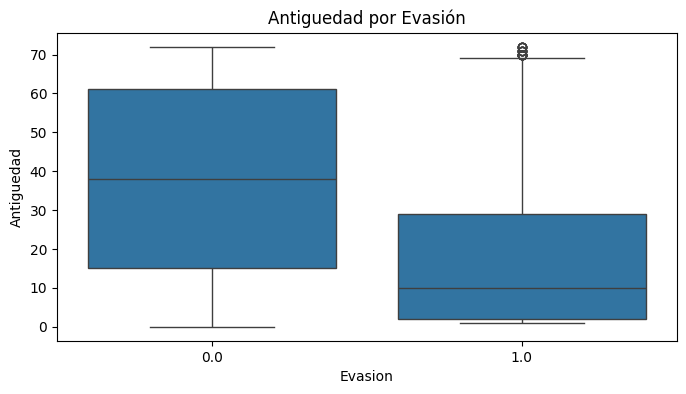

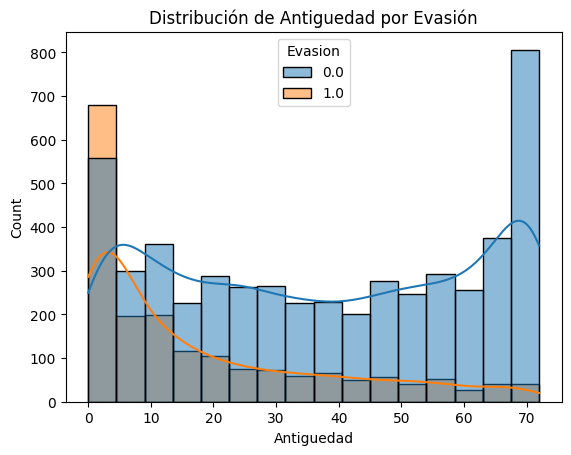

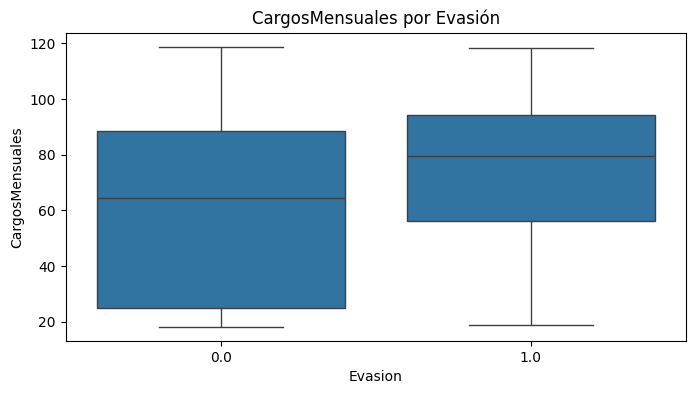

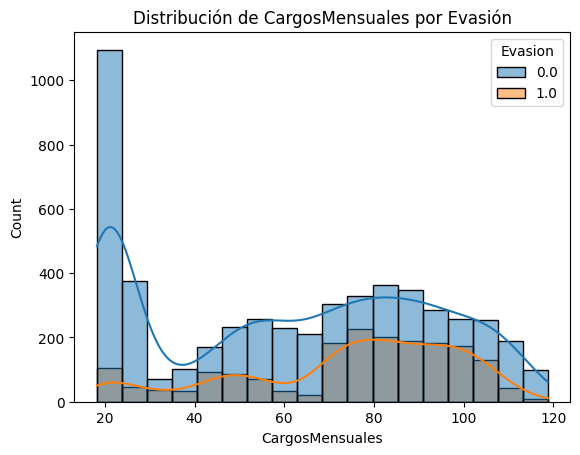

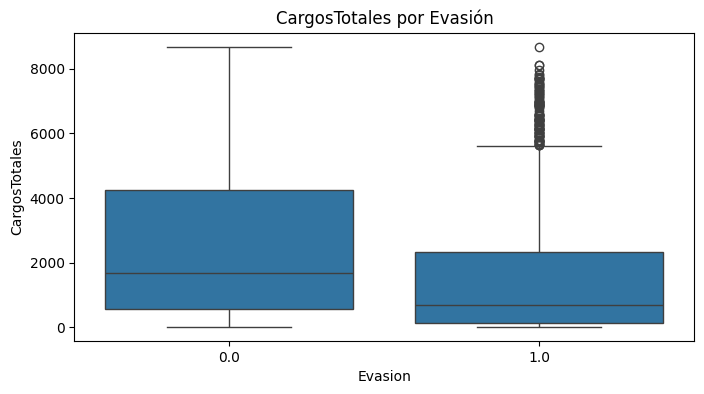

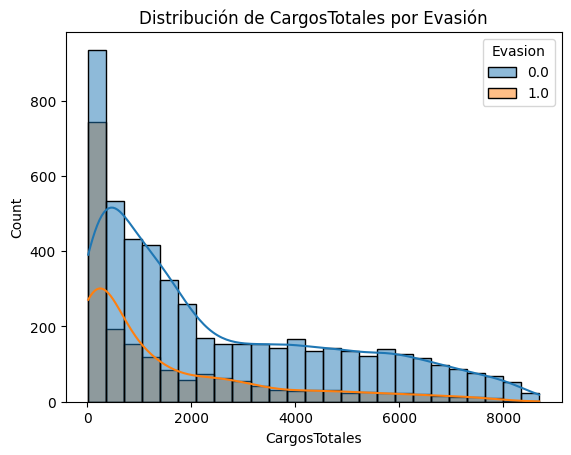

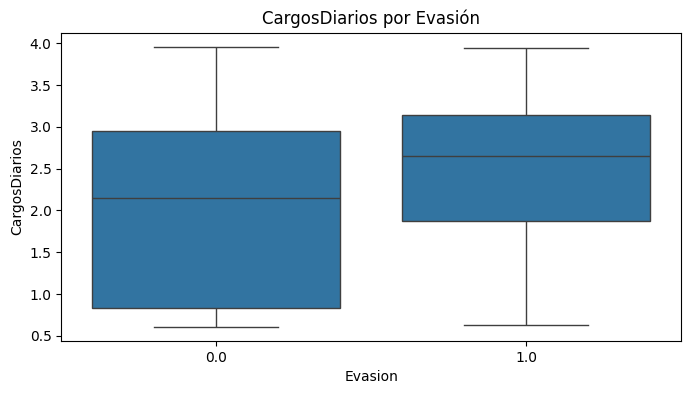

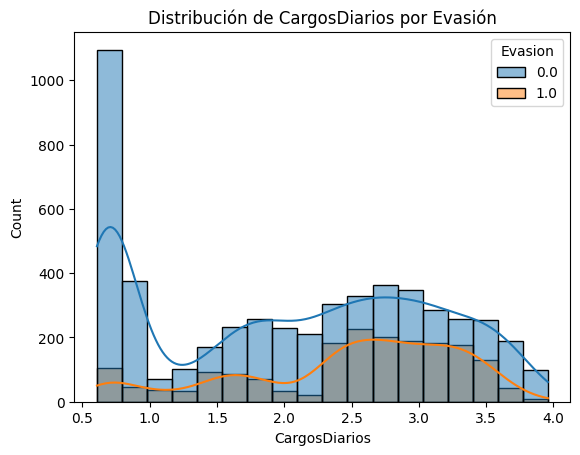

In [ ]:
num_vars = ['Antiguedad', 'CargosMensuales', 'CargosTotales', 'CargosDiarios']

for var in num_vars:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='Evasion', y=var, data=df)
    plt.title(f'{var} por Evasión')
    plt.show()

    # Histograma
    sns.histplot(data=df, x=var, hue='Evasion', kde=True)
    plt.title(f'Distribución de {var} por Evasión')
    plt.show()

##Análisis de Correlación (Extra)
Correlaciones entre variables.

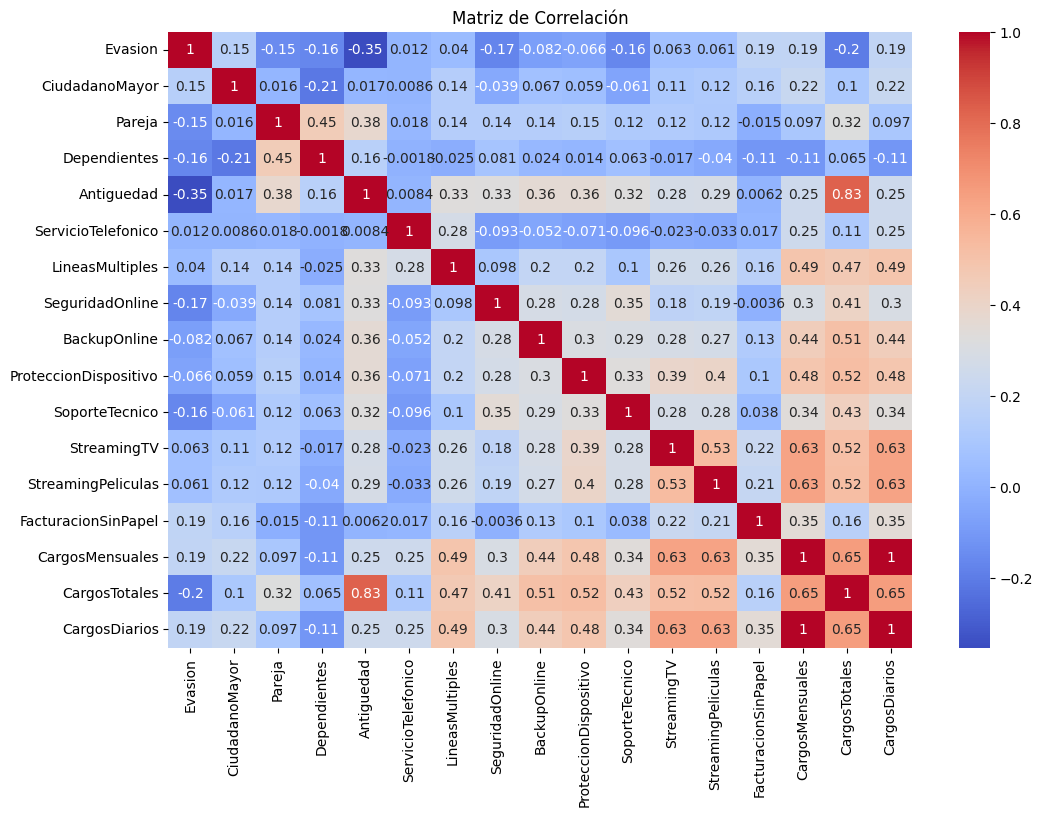

Evasion                  1.000000
CargosMensuales          0.193356
CargosDiarios            0.193356
FacturacionSinPapel      0.191825
CiudadanoMayor           0.150889
StreamingTV              0.063228
StreamingPeliculas       0.061382
LineasMultiples          0.040102
ServicioTelefonico       0.011942
ProteccionDispositivo   -0.066160
BackupOnline            -0.082255
Pareja                  -0.150448
Dependientes            -0.164221
SoporteTecnico          -0.164674
SeguridadOnline         -0.171226
CargosTotales           -0.199484
Antiguedad              -0.352229
Name: Evasion, dtype: float64


In [ ]:
# Seleccionar numéricas y binarias
corr_df = df.select_dtypes(include=['float64', 'int64'])

# Matriz de correlación
corr_matrix = corr_df.corr()

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

# Correlación con Evasión
print(corr_matrix['Evasion'].sort_values(ascending=False))

##Conclusiones e Insights

* La tasa de churn es aproximadamente 26%
* Clientes con contratos mensuales tienen mayor churn que anuales.
* Métodos de pago electrónicos están asociados con mayor churn.
* Mayor antigüedad y cargos totales reducen churn.
* Servicios adicionales como soporte técnico reducen churn.
* Ciudadanos mayores y sin dependientes churn más.


##Recomendaciones

* Ofrecer descuentos para contratos a largo plazo.
* Mejorar soporte para clientes con pagos electrónicos.
* Programas de retención para seniors y clientes nuevos (baja antigüedad).
* Bundles con servicios adicionales para reducir churn.
* Monitorear cargos diarios/mensuales para identificar riesgos.

##Extrayendo conjunto de datos que limpios y transformados

In [ ]:
df.to_csv("datos_tratados.csv", index=False)

# CHALLENGE 2 TELECOM X ANALISIS DE EVACION DE CLIENTES PARTE II

##💡Acerca del desafío 💡
Telecom X – Parte 2: Predicción de Cancelación (Churn)

📣 Historia del Desafío

¡Felicidades! 🎉 Has sido promovido después de tu excelente desempeño en el análisis exploratorio de la cancelación de clientes en Telecom X. Tu dedicación, claridad al comunicar los datos y visión estratégica marcaron la diferencia.

Ahora, ¡has sido invitado oficialmente a formar parte del equipo de Machine Learning de la empresa!

🎯 Misión

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

🧠 Objetivos del Desafío

Preparar los datos para el modelado (tratamiento, codificación, normalización).

Realizar análisis de correlación y selección de variables.

Entrenar dos o más modelos de clasificación.

Evaluar el rendimiento de los modelos con métricas.

Interpretar los resultados, incluyendo la importancia de las variables.

Crear una conclusión estratégica señalando los principales factores que influyen en la cancelación.

🧰 Lo que vas a practicar

✅ Preprocesamiento de datos para Machine Learning
✅ Construcción y evaluación de modelos predictivos
✅ Interpretación de resultados y entrega de insights
✅ Comunicación técnica con enfoque estratégico

🚀 Ahora eres: Analista Junior de Machine Learning

Telecom X confía en tu entrega para dar los próximos pasos hacia una solución de inteligencia predictiva eficaz. ¡Buena suerte!

In [ ]:
df = '/content/datos_tratados.csv'

## Bibliotecas necesarias

In [ ]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.inspection import permutation_importance

## ETAPA 1: Preparación de los Datos

###Extracción del Archivo Tratado
Carga el archivo CSV que contiene los datos tratados anteriormente.
📂 Atención: Utiliza el mismo archivo que limpiaste y organizaste en la Parte 1 del desafío Telecom X. Debe contener solo las columnas relevantes, ya con los datos corregidos y estandarizados.

### Eliminación de Columnas Irrelevantes

Elimina columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

### Encoding

Transforma las variables categóricas a formato numérico para hacerlas compatibles con los algoritmos de machine learning. Utiliza un método de codificación adecuado, como one-hot encoding.

🔎 Sugerencia:
Puedes consultar este artículo para entender mejor cuándo usar get_dummies o OneHotEncoder:

### Verificación de la Proporción de Cancelación (Churn)

Calcula la proporción de clientes que cancelaron en relación con los que permanecieron activos. Evalúa si existe un desbalance entre las clases, ya que esto puede impactar en los modelos predictivos y en el análisis de los resultados.

🔎 Sugerencia:
Puedes usar value_counts() de pandas para obtener esta proporción:
Documentación oficial de value_counts()

###Balanceo de Clases (opcional)

Si deseas profundizar en el análisis, aplica técnicas de balanceo como undersampling o oversampling. En situaciones de fuerte desbalanceo, herramientas como SMOTE pueden ser útiles para generar ejemplos sintéticos de la clase minoritaria.

🔎 Sugerencia:
Puedes leer más sobre cómo manejar el desbalanceo de clases en este artículo:

### Normalización o Estandarización (si es necesario)

Evalúa la necesidad de normalizar o estandarizar los datos, según los modelos que se aplicarán. Modelos basados en distancia, como KNN, SVM, Regresión Logística y Redes Neuronales, requieren este preprocesamiento. Por otro lado, modelos basados en árboles, como Decision Tree, Random Forest y XGBoost, no son sensibles a la escala de los datos.

🔎 Sugerencia:
Puedes leer más sobre normalización y estandarización de datos en este artículo:

In [ ]:
df = pd.read_csv('/content/datos_tratados.csv')
print("Columnas originales:", df.columns.tolist())
df = df.drop('customerID', axis=1) #Eliminación de Columnas Irrelevantes

# Manejo de nulls
df['CargosTotales'] = df['CargosTotales'].fillna(df['CargosTotales'].median())
print("Nulls después:", df.isnull().sum().sum())

print("Forma del DataFrame después de eliminar columnas:", df.shape)
df.head()

Columnas originales: ['customerID', 'Evasion', 'Genero', 'CiudadanoMayor', 'Pareja', 'Dependientes', 'Antiguedad', 'ServicioTelefonico', 'LineasMultiples', 'ServicioInternet', 'SeguridadOnline', 'BackupOnline', 'ProteccionDispositivo', 'SoporteTecnico', 'StreamingTV', 'StreamingPeliculas', 'Contrato', 'FacturacionSinPapel', 'MetodoPago', 'CargosMensuales', 'CargosTotales', 'CargosDiarios']
Nulls después: 0
Forma del DataFrame después de eliminar columnas: (7043, 21)


,Evasion,Genero,CiudadanoMayor,Pareja,Dependientes,Antiguedad,ServicioTelefonico,LineasMultiples,ServicioInternet,SeguridadOnline,...,ProteccionDispositivo,SoporteTecnico,StreamingTV,StreamingPeliculas,Contrato,FacturacionSinPapel,MetodoPago,CargosMensuales,CargosTotales,CargosDiarios
0,0.0,female,0,1.0,1.0,9,1.0,0.0,dsl,0.0,...,0.0,1.0,1.0,0.0,one_year,1.0,mailed_check,65.6,593.30,2.186667
1,0.0,male,0,0.0,0.0,9,1.0,1.0,dsl,0.0,...,0.0,0.0,0.0,1.0,month-to-month,0.0,mailed_check,59.9,542.40,1.996667
2,1.0,male,0,0.0,0.0,4,1.0,0.0,fiber_optic,0.0,...,1.0,0.0,0.0,0.0,month-to-month,1.0,electronic_check,73.9,280.85,2.463333
3,1.0,male,1,1.0,0.0,13,1.0,0.0,fiber_optic,0.0,...,1.0,0.0,1.0,1.0,month-to-month,1.0,electronic_check,98.0,1237.85,3.266667
4,1.0,female,1,1.0,0.0,3,1.0,0.0,fiber_optic,0.0,...,0.0,1.0,1.0,0.0,month-to-month,1.0,mailed_check,83.9,267.40,2.796667


In [ ]:
# 2. Transforma variables categóricas a numéricas
# Usamos pd.get_dummies con drop_first=True para manejar multicolinealidad
categorical_cols = ['Genero', 'ServicioInternet', 'Contrato', 'MetodoPago']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Forma después de dummies:", df.shape)
df.head()

Forma después de dummies: (7043, 25)


,Evasion,CiudadanoMayor,Pareja,Dependientes,Antiguedad,ServicioTelefonico,LineasMultiples,SeguridadOnline,BackupOnline,ProteccionDispositivo,...,CargosTotales,CargosDiarios,Genero_male,ServicioInternet_fiber_optic,ServicioInternet_no,Contrato_one_year,Contrato_two_year,MetodoPago_credit_card_(automatic),MetodoPago_electronic_check,MetodoPago_mailed_check
0,0.0,0,1.0,1.0,9,1.0,0.0,0.0,1.0,0.0,...,593.30,2.186667,False,False,False,True,False,False,False,True
1,0.0,0,0.0,0.0,9,1.0,1.0,0.0,0.0,0.0,...,542.40,1.996667,True,False,False,False,False,False,False,True
2,1.0,0,0.0,0.0,4,1.0,0.0,0.0,0.0,1.0,...,280.85,2.463333,True,True,False,False,False,False,True,False
3,1.0,1,1.0,0.0,13,1.0,0.0,0.0,1.0,1.0,...,1237.85,3.266667,True,True,False,False,False,False,True,False
4,1.0,1,1.0,0.0,3,1.0,0.0,0.0,0.0,0.0,...,267.40,2.796667,False,True,False,False,False,False,False,True


In [ ]:
# 3. Calcula la proporción de clases en la variable objetivo
# Evaluamos desbalanceo
class_proportion = df['Evasion'].value_counts(normalize=True)
print("Proporción de clases:\n", class_proportion)
# Desbalance significativo si ratio >2:1 (clase 0 > 2* clase 1)

Proporción de clases:
 Evasion
0.0    0.73463
1.0    0.26537
Name: proportion, dtype: float64


- Proporción de clientes activos (no churn): 73.463% (0.73463)
- Proporción de clientes que cancelaron (churn): 26.537% (0.26537)

Esto representa una relación aproximada de 2.77:1 (clase mayoritaria vs. minoritaria).

existe un desbalance significativo entre las clases, ya que la clase minoritaria (churn) representa menos del 30% del total y la relación supera el umbral común de 2:1. Este desbalance puede impactar negativamente en los modelos predictivos

In [ ]:
# 4. Aplica balanceo si hay desbalance significativo
# Usamos SMOTE para oversampling; aplicamos solo en train después de split.
# SMOTE genera muestras sintéticas de la clase minoritaria, mejorando recall sin overfitting.
# Se aplica después del split para evitar data leakage.

In [ ]:
# 5. Evalúa y aplica normalización/estandarización
# Usaremos StandardScaler para modelos sensibles como LogisticRegression
# No para RandomForest.
numerical_cols = ['Antiguedad', 'CargosMensuales', 'CargosTotales', 'CargosDiarios']

## ETAPA 2: Correlación y Selección de Variables

###Análisis de Correlación
Visualiza la matriz de correlación para identificar relaciones entre las variables numéricas. Presta especial atención a las variables que muestran una mayor correlación con la cancelación, ya que estas pueden ser fuertes candidatas para el modelo predictivo.

###Análisis Dirigido
Investiga cómo variables específicas se relacionan con la cancelación, tales como:

Tiempo de contrato × Cancelación

Gasto total × Cancelación

Utiliza gráficos como boxplots o scatter plots para visualizar patrones y posibles tendencias.

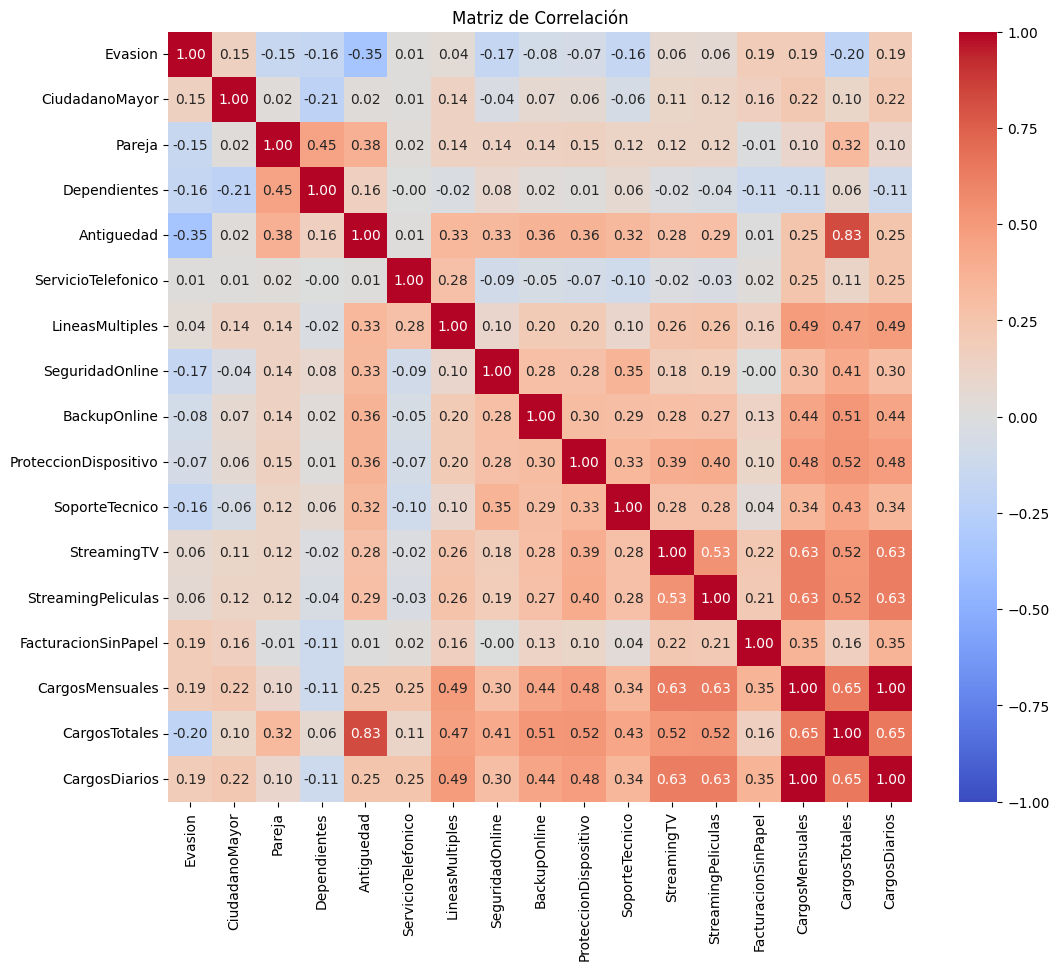

Correlaciones con Evasion:
 Evasion                  1.000000
CargosMensuales          0.193356
CargosDiarios            0.193356
FacturacionSinPapel      0.191825
CiudadanoMayor           0.150889
StreamingTV              0.063228
StreamingPeliculas       0.061382
LineasMultiples          0.040102
ServicioTelefonico       0.011942
ProteccionDispositivo   -0.066160
BackupOnline            -0.082255
Pareja                  -0.150448
Dependientes            -0.164221
SoporteTecnico          -0.164674
SeguridadOnline         -0.171226
CargosTotales           -0.199037
Antiguedad              -0.352229
Name: Evasion, dtype: float64


In [ ]:
# 1. Calcula y visualiza la matriz de correlación para variables numéricas
# Usando seaborn.heatmap
num_df = df.select_dtypes(include=['float64', 'int64'])
corr_matrix = num_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()
# Identifica correlaciones fuertes con 'Evasion' (e.g., >|0.1|).
print("Correlaciones con Evasion:\n", corr_matrix['Evasion'].sort_values(ascending=False))

Correlaciones multicolineales: Hay relaciones fuertes entre variables relacionadas, como CargosMensuales y CargosDiarios (1.00, ya que son derivadas), o CargosTotales con Antiguedad (0.83, lógico ya que el total acumula con el tiempo).

Correlaciones débiles en general: La mayoría de las correlaciones son bajas (<|0.5|), indicando que no hay dependencias lineales extremas, pero sí patrones útiles para ML

Variables agrupadas: Servicios adicionales (e.g., StreamingTV, StreamingPeliculas) muestran correlaciones positivas moderadas entre sí (0.53-0.63), lo que implica que clientes con uno suelen tener otros.

CargosMensuales (0.193) y CargosDiarios (0.193): Clientes con cargos mensuales/diarios más altos tienden a cancelar más. Esto sugiere sensibilidad al precio; fuerte candidata para modelos, ya que altos costos impulsan churn.


CiudadanoMayor (0.151): Seniors tienen mayor tasa de churn, quizás por insatisfacción.

Correlaciones negativas fuertes (reducen probabilidad de churn):


Antiguedad (-0.352): Mayor tiempo como cliente reduce churn significativamente. Esta es la correlación más fuerte, haciendo de Antiguedad una variable clave para predicción (lealtad acumulada).


SeguridadOnline (-0.171), SoporteTecnico (-0.165): Servicios de soporte y seguridad retienen clientes, indicando que protección adicional fomenta lealtad.


Dependientes (-0.164), Pareja (-0.150): Clientes con familia o pareja son menos propensos a cancelar, posiblemente por dependencias compartidas.

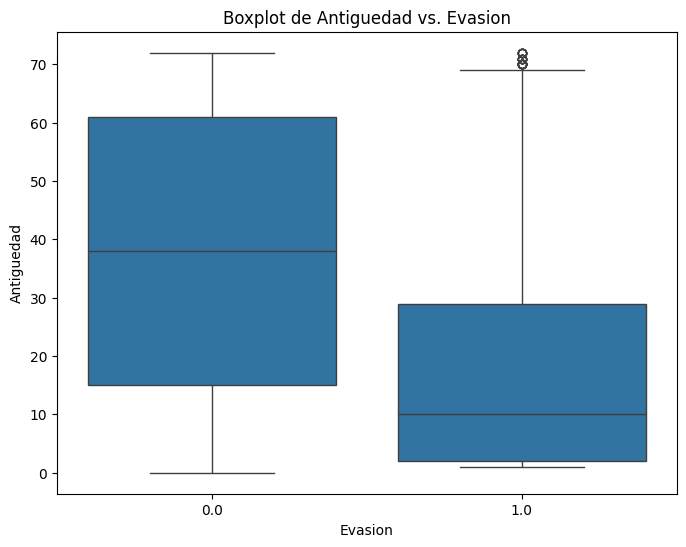

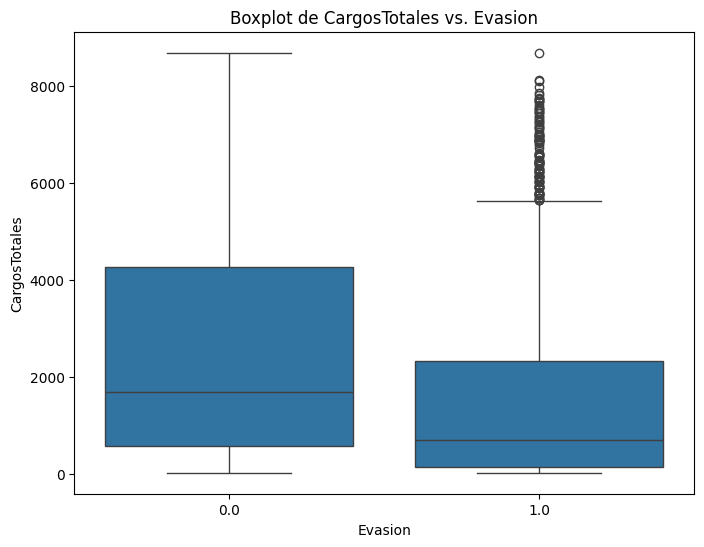

In [ ]:
# 2. Analiza variables específicas vs. cancelación
# Boxplots
# Asumimos columnas como 'Antiguedad' (tiempo_contrato), 'CargosTotales' (gasto_total).

# Boxplot para Antiguedad vs. Evasion
plt.figure(figsize=(8, 6))
sns.boxplot(x='Evasion', y='Antiguedad', data=df)
plt.title('Boxplot de Antiguedad vs. Evasion')
plt.show()

# Boxplot para CargosTotales vs. Evasion
plt.figure(figsize=(8, 6))
sns.boxplot(x='Evasion', y='CargosTotales', data=df)
plt.title('Boxplot de CargosTotales vs. Evasion')
plt.show()

## ETAPA 3: Modelado Predictivo

###Separación de Datos
Divide el conjunto de datos en entrenamiento y prueba para evaluar el rendimiento del modelo. Una división común es 70% para entrenamiento y 30% para prueba, o 80/20, dependiendo del tamaño de la base de datos.

###Creación de Modelos
Crea al menos dos modelos diferentes para predecir la cancelación de clientes.

Un modelo puede requerir normalización, como Regresión Logística o KNN.

El otro modelo puede no requerir normalización, como Árbol de Decisión o Random Forest.

💡 La decisión de aplicar o no la normalización depende de los modelos seleccionados. Ambos modelos pueden ser creados sin normalización, pero también es una opción combinar modelos con y sin normalización.

Justificación:

Regresión Logística / KNN: Estos modelos son sensibles a la escala de los datos, por lo que la normalización es importante para que los coeficientes o las distancias se calculen correctamente.

Árbol de Decisión / Random Forest: Estos modelos no dependen de la escala de los datos, por lo que no es necesario aplicar normalización.

Si decides normalizar los datos, deberías explicar cómo esta etapa asegura que los modelos basados en distancia o en optimización de parámetros no se vean sesgados por la magnitud de las variables.


###Evaluación de los Modelos
Evalúa cada modelo utilizando las siguientes métricas:

Exactitud (Acurácia)

Precisión

Recall

F1-score

Matriz de confusión

Después, realiza un análisis crítico y compara los modelos:

¿Cuál modelo tuvo el mejor desempeño?

¿Algún modelo presentó overfitting o underfitting? Si es así, considera las posibles causas y ajustes:

Overfitting: Cuando el modelo aprende demasiado sobre los datos de entrenamiento, perdiendo la capacidad de generalizar a nuevos datos. Considera reducir la complejidad del modelo o aumentar los datos de entrenamiento.

Underfitting: Cuando el modelo no captura bien las tendencias de los datos, lo que indica que es demasiado simple. Intenta aumentar la complejidad del modelo o ajustar sus parámetros.



In [ ]:
# 1. Divide los datos en X (features) e y (objetivo), luego en train/test
# Usando train_test_split Usamos 70% entrenamiento y 30% prueba, adecuado para ~7000 registros
X = df.drop('Evasion', axis=1)
y = df['Evasion']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print("Forma de train/test:", X_train.shape, X_test.shape)
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de train/test: (4930, 24) (2113, 24)
Forma de X_train: (4930, 24)
Forma de X_test: (2113, 24)
Forma de y_train: (4930,)
Forma de y_test: (2113,)


In [ ]:
# Aplicar SMOTE solo en train si desbalance
if class_proportion[0] / class_proportion[1] > 2:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("Forma de train después de SMOTE:", X_train.shape)

Forma de train después de SMOTE: (7224, 24)


In [ ]:
# 2. entrenando Dos modelos de clasificación
# Uno sensible a escala: LogisticRegression con normalización.
# Uno no sensible: RandomForestClassifier.

# Normalización para LR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo 1: LogisticRegression
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)

# Modelo 2: RandomForestClassifier
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Sección de Modelos: Regresión Logística (sensible a escala)
Estos modelos requieren normalización para un cálculo preciso de coeficientes (lección notebooks 03-05: evita sesgos en distancias o gradientes).

LogisticRegression - Train Report:
               precision    recall  f1-score   support

         0.0       0.81      0.79      0.80      3612
         1.0       0.79      0.82      0.81      3612

    accuracy                           0.80      7224
   macro avg       0.80      0.80      0.80      7224
weighted avg       0.80      0.80      0.80      7224

LogisticRegression - Test Report:
               precision    recall  f1-score   support

         0.0       0.88      0.78      0.83      1562
         1.0       0.53      0.69      0.60       551

    accuracy                           0.76      2113
   macro avg       0.70      0.74      0.71      2113
weighted avg       0.79      0.76      0.77      2113



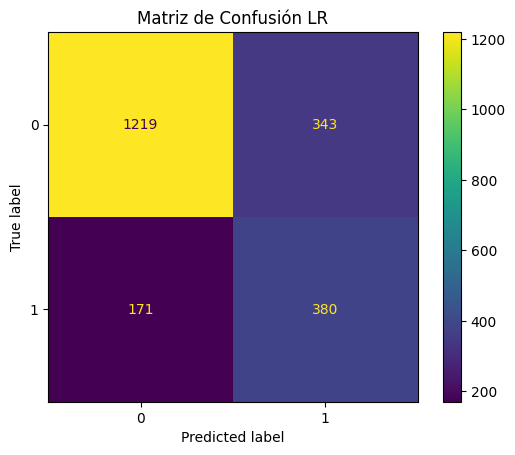

RandomForest - Train Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      3612
         1.0       1.00      1.00      1.00      3612

    accuracy                           1.00      7224
   macro avg       1.00      1.00      1.00      7224
weighted avg       1.00      1.00      1.00      7224

RandomForest - Test Report:
               precision    recall  f1-score   support

         0.0       0.84      0.88      0.86      1562
         1.0       0.60      0.51      0.55       551

    accuracy                           0.79      2113
   macro avg       0.72      0.70      0.71      2113
weighted avg       0.78      0.79      0.78      2113



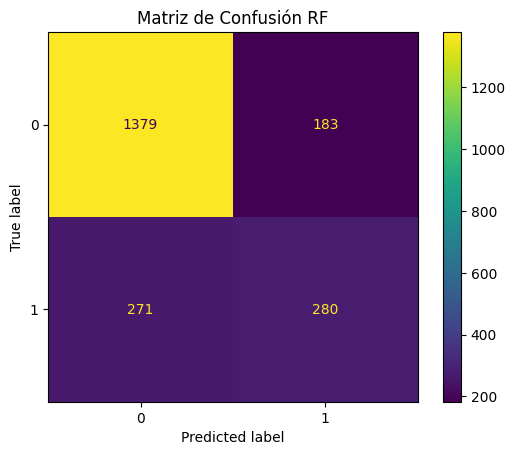

In [ ]:
# 3. Evalúa cada modelo en el set de test
# Métricas: classification_report, matriz de confusión
# Análisis de overfitting/underfitting comparando train vs. test.

# Evaluación LR
print("LogisticRegression - Train Report:\n", classification_report(y_train, lr.predict(X_train_scaled)))
print("LogisticRegression - Test Report:\n", classification_report(y_test, lr.predict(X_test_scaled)))
cm_lr = confusion_matrix(y_test, lr.predict(X_test_scaled))
ConfusionMatrixDisplay(cm_lr).plot()
plt.title('Matriz de Confusión LR')
plt.show()

# Evaluación RF
print("RandomForest - Train Report:\n", classification_report(y_train, rf.predict(X_train)))
print("RandomForest - Test Report:\n", classification_report(y_test, rf.predict(X_test)))
cm_rf = confusion_matrix(y_test, rf.predict(X_test))
ConfusionMatrixDisplay(cm_rf).plot()
plt.title('Matriz de Confusión RF')
plt.show()

# Análisis: Compara accuracy train vs test para detectar over/underfitting.
# Si overfitting en RF (train ~1.0, test bajo), sugerir: rf = RandomForestClassifier(max_depth=10, min_samples_leaf=4)

## ETAPA 4: Interpretación y Conclusiones

###Análisis de la Importancia de las Variables
Después de elegir los modelos, realiza el análisis de las variables más relevantes para la predicción de la cancelación:

Regresión Logística: Investiga los coeficientes de las variables, que muestran su contribución a la predicción de cancelación.

KNN (K-Nearest Neighbors): Observa cómo los vecinos más cercanos influyen en la decisión de clasificación. Las variables más impactantes pueden ser aquellas que más contribuyen a la proximidad entre los puntos de datos.

Random Forest: Utiliza la importancia de las variables proporcionada por el modelo. Random Forest calcula la importancia basándose en cómo cada variable contribuye a la reducción de la impureza durante las divisiones de los árboles.

SVM (Support Vector Machine): En el SVM, las variables más relevantes son aquellas que influyen en la frontera de decisión entre las clases. Puedes analizar los coeficientes de los vectores de soporte para entender qué variables tienen mayor impacto.

Otros Modelos: Dependiendo del modelo elegido, considera el análisis de métricas específicas para comprender la relevancia de las variables. Por ejemplo, coeficientes en modelos lineales, pesos en redes neuronales, o la importancia relativa en técnicas de boosting (como XGBoost).

###Conclusión
Elaboren un informe detallado, destacando los factores que más influyen en la cancelación, basándose en las variables seleccionadas y en el rendimiento de cada modelo.

Identifiquen los principales factores que afectan la cancelación de clientes y propongan estrategias de retención basadas en los resultados obtenidos.

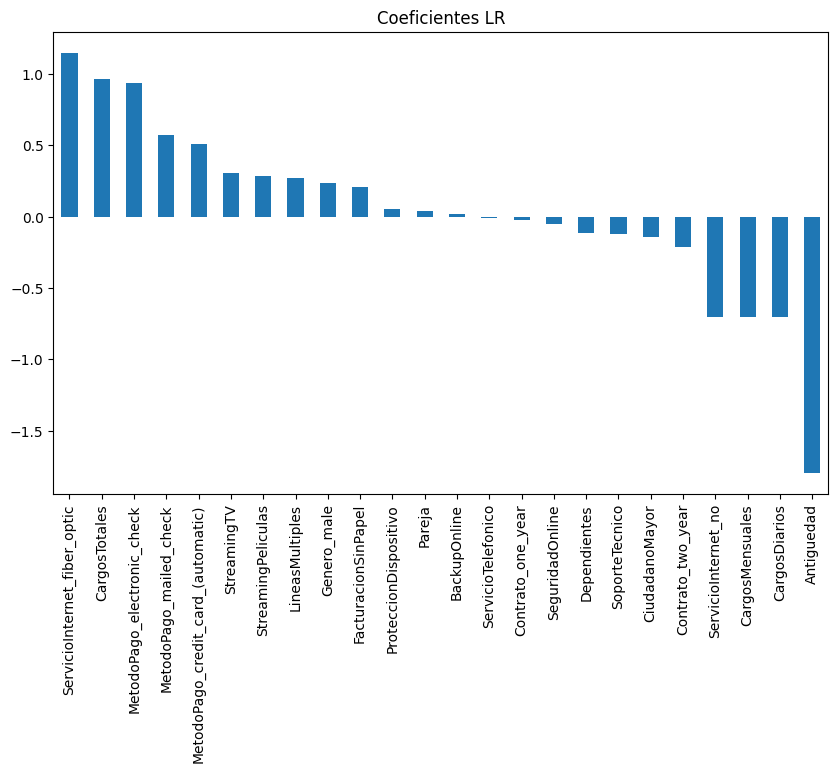

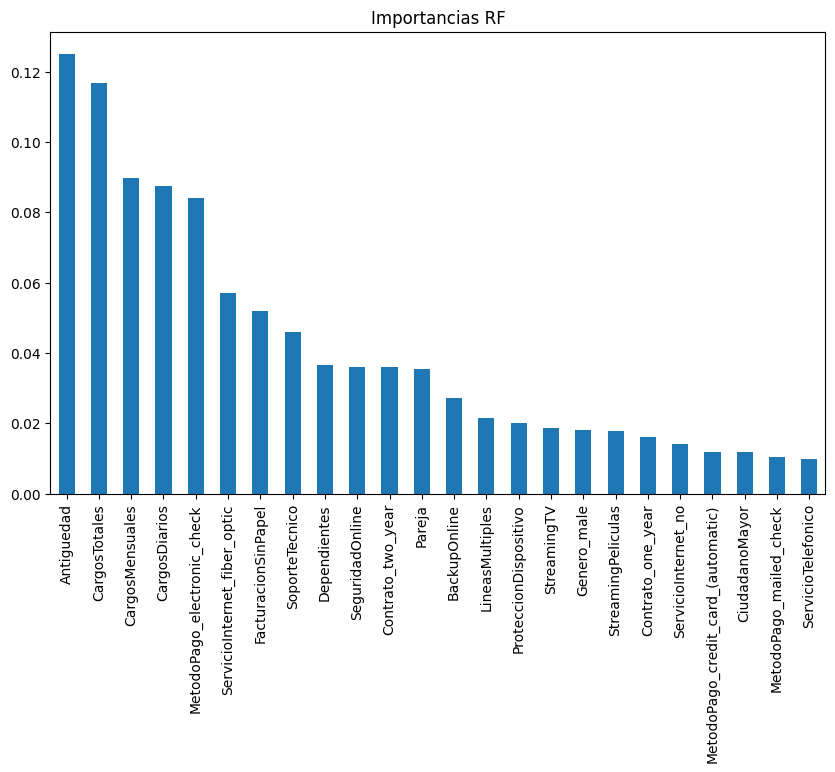

In [ ]:
# 1. Analiza importancia de variables por modelo
# LR: Coeficientes.
# RF: feature_importances_.

# Importancia LR
importances_lr = pd.Series(lr.coef_[0], index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances_lr.plot(kind='bar')
plt.title('Coeficientes LR')
plt.show()

# Importancia RF
importances_rf = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances_rf.plot(kind='bar')
plt.title('Importancias RF')
plt.show()

2. Informe detallado:
- Resumen rendimiento: Compara F1-score (mejor para desbalance). Ej: RF mejor si F1 macro superior.
- Factores clave: Basado en importancias, e.g., bajo Antiguedad, alto CargosMensuales aumentan cancelación.
- Estrategias: Descuentos para contratos largos, soporte para servicios de internet.
- Insights holísticos: Integrar EDA, preproc, modelado

**Conclusión estratégica**  
Basado en los modelos, identificar clientes en riesgo y aplicar retención proactiva. Mejoras: Tuning hiperparámetros, más datos o modelos avanzados como XGBoost.